In [ ]:
%pip install opendatasets tensorflow opencv-python scikit-learn imutils gradio tf2onnx seaborn tqdm Pillow scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\My PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 149M/149M [00:09<00:00, 16.3MB/s] 


In [ ]:
import os
import random
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from IPython.display import Image
import imutils
import tensorflow as tf
from tensorflow.keras import mixed_precision

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ── Mixed Precision Training (2-3x GPU speedup) ───────────────────────────────
mixed_precision.set_global_policy('mixed_float16')
print(f"Compute dtype : {mixed_precision.global_policy().compute_dtype}")
print(f"Variable dtype: {mixed_precision.global_policy().variable_dtype}")

In [ ]:
# ── Base Paths (relative, works on macOS / Linux / Windows) ──────────────────
BASE_DIR      = Path(".")
DATASET_DIR   = BASE_DIR / "brain-tumor-mri-dataset"
CROP_DIR      = BASE_DIR / "Crop-Brain-MRI"
TEST_DATA_DIR = BASE_DIR / "Test-Data"
CLASSES       = ["glioma", "meningioma", "notumor", "pituitary"]

for cls in CLASSES:
    (CROP_DIR / cls).mkdir(parents=True, exist_ok=True)
    (TEST_DATA_DIR / cls).mkdir(parents=True, exist_ok=True)

print("All output directories ready.")

In [6]:
# Data Visulization

In [ ]:
train_dir = DATASET_DIR / "Training"
test_dir  = DATASET_DIR / "Testing"

In [ ]:
classes = [c for c in os.listdir(train_dir) if not c.startswith('.')]

In [9]:
classes

['glioma', 'meningioma', 'notumor', 'pituitary']

In [ ]:
filepath_dict = {}

for c in classes:
    filepath_dict[c] = [str(train_dir / c / x)
                        for x in os.listdir(train_dir / c)
                        if not x.startswith('.')]

In [11]:
filepath_dict

{'glioma': ['D:/Adi projects/brain tumour detection/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0000.jpg',
  'D:/Adi projects/brain tumour detection/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0001.jpg',
  'D:/Adi projects/brain tumour detection/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0002.jpg',
  'D:/Adi projects/brain tumour detection/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0003.jpg',
  'D:/Adi projects/brain tumour detection/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0004.jpg',
  'D:/Adi projects/brain tumour detection/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0005.jpg',
  'D:/Adi projects/brain tumour detection/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0006.jpg',
  'D:/Adi projects/brain tumour detection/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0007.jpg',
  'D:/Adi projects/brain tumour detection/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0008.jpg',
  'D:/Adi projects/brain tumour detection/brain-tumor-mri-dataset/Training/glioma

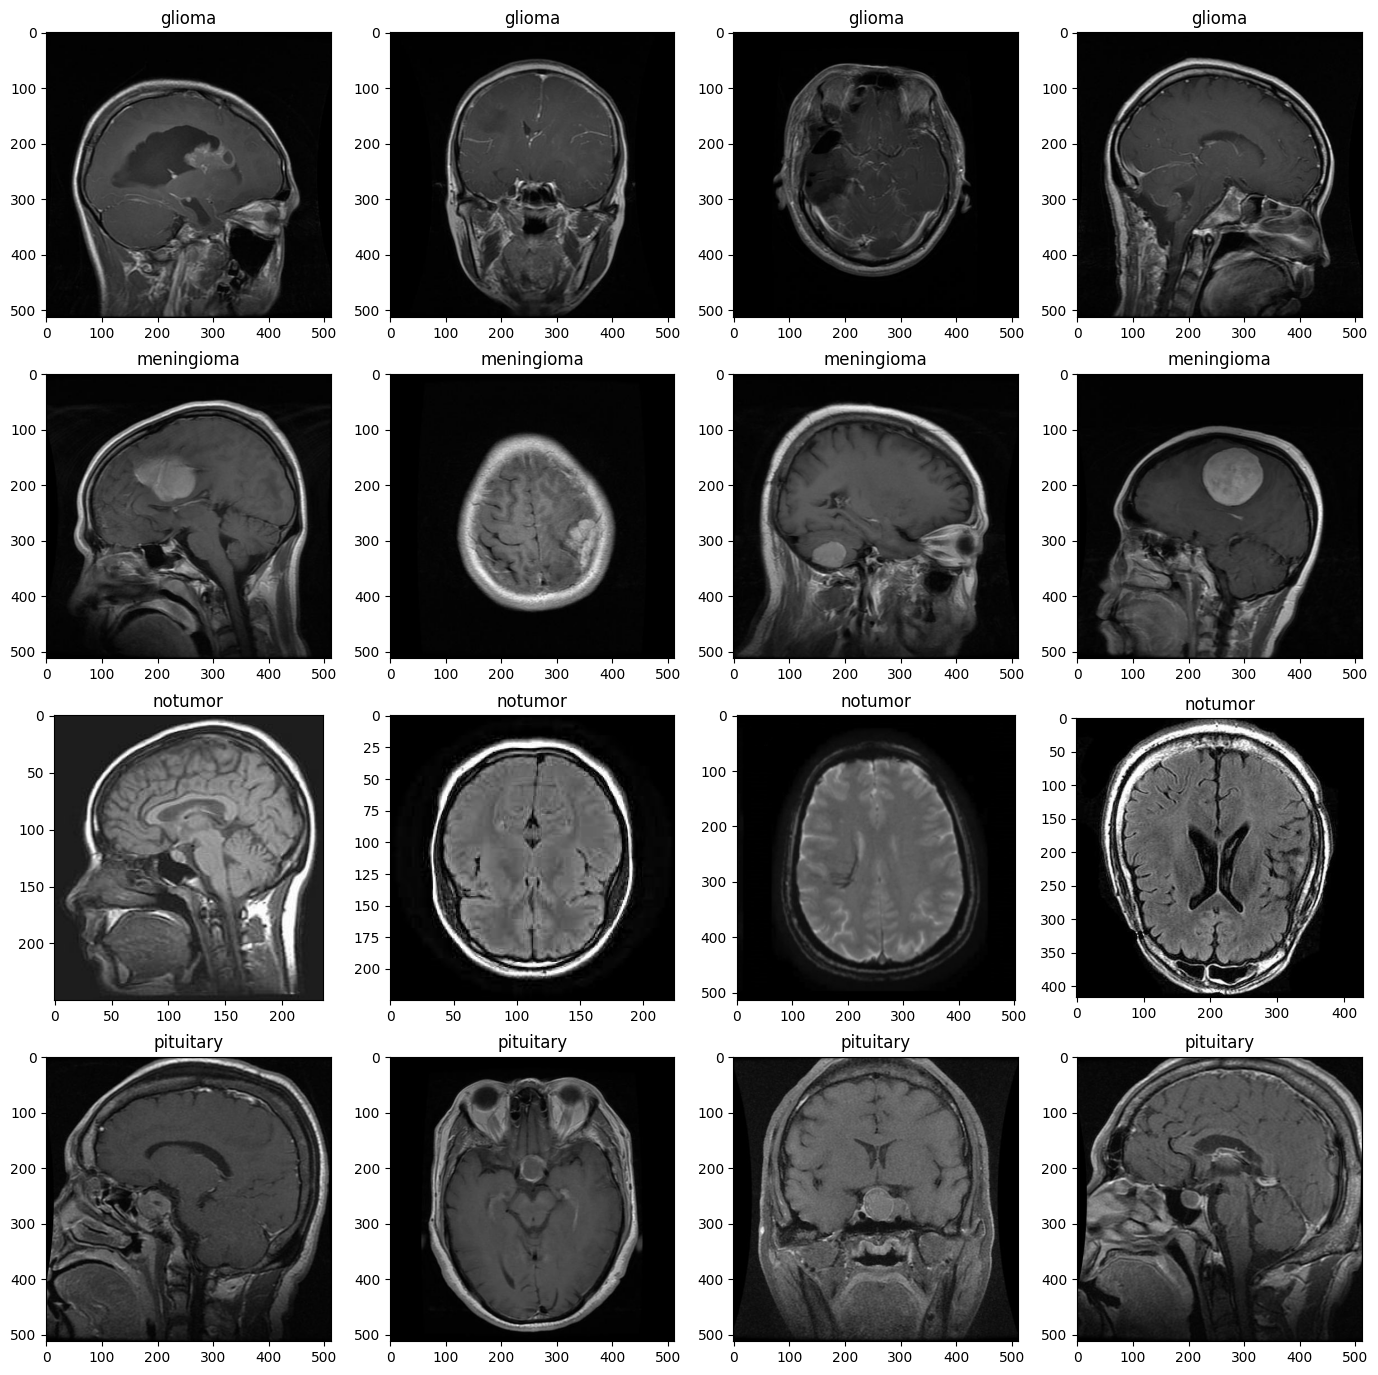

In [12]:
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize = (17, 17))

index = 0

for c in classes:
  random.shuffle(filepath_dict[c])
  path_list = filepath_dict[c][:5]

  for i in range(1, 5):
    index +=1
    plt.subplot(4, 4,index)
    plt.imshow(load_img(path_list[i]))
    plt.title(c)

In [ ]:
No_images_per_class = []
Class_name = []

for cls in classes:
    count = len([f for f in os.listdir(train_dir / cls) if not f.startswith('.')])
    No_images_per_class.append(count)
    Class_name.append(cls)
    print(f"Number of images in {cls} : {count}")

Number of images in glioma : 1321
Number of images in meningioma : 1339
Number of images in notumor : 1595
Number of images in pituitary : 1457


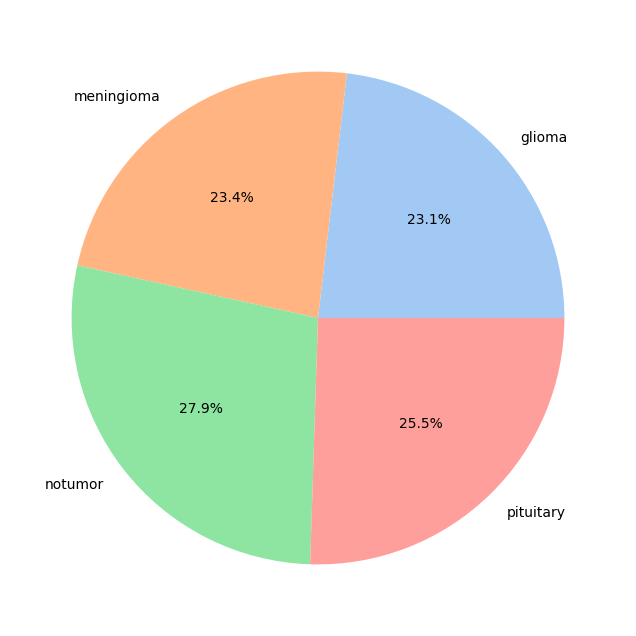

In [14]:
plt.figure(figsize =(8, 8))
colors = sns.color_palette('pastel')
plt.pie(No_images_per_class, labels = Class_name, autopct = "%1.1f%%", colors = colors)
plt.show()

In [ ]:
def preprocess_mri_clahe(image):
    """CLAHE contrast enhancement — clinical radiology standard for MRI."""
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    enhanced = cv2.merge((l_enhanced, a, b))
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)


def crop_image(image, plot=False):
    img_gray   = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    img_blur   = cv2.GaussianBlur(img_gray, (5, 5), 0)
    img_thresh = cv2.threshold(img_blur, 45, 255, cv2.THRESH_BINARY)[1]
    img_thresh = cv2.erode(img_thresh, None, iterations=2)
    img_thresh = cv2.dilate(img_thresh, None, iterations=2)

    contours = cv2.findContours(img_thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contours = imutils.grab_contours(contours)

    # FIX: return original if no contours found
    if not contours:
        return image

    c        = max(contours, key=cv2.contourArea)
    extLeft  = tuple(c[c[:, :, 0].argmin()])[0]
    extRight = tuple(c[c[:, :, 0].argmax()])[0]
    extTop   = tuple(c[c[:, :, 1].argmin()])[0]
    extBottom= tuple(c[c[:, :, 1].argmax()])[0]

    new_img = image[extTop[1]:extBottom[1], extLeft[0]:extRight[0]]

    # FIX: return original if crop region is empty
    if new_img is None or new_img.size == 0:
        return image

    if plot:
        plt.figure(figsize=(15, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title("Original Image")
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB))
        plt.title("Cropped Image")
        plt.show()

    return new_img

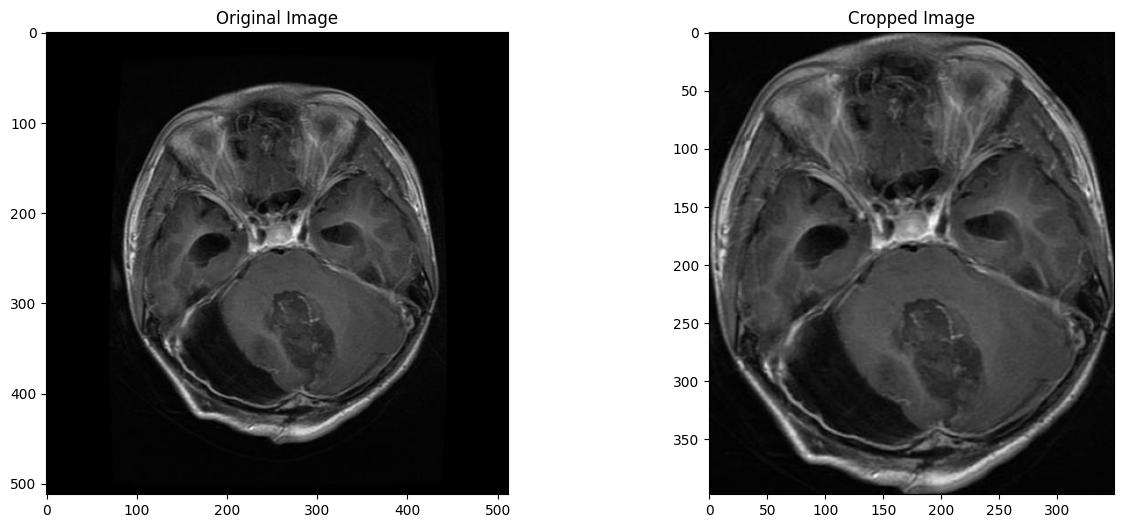

In [ ]:
example_img = cv2.imread(str(test_dir / "glioma" / "Te-glTr_0000.jpg"))
cropped_img = crop_image(example_img, plot=True)

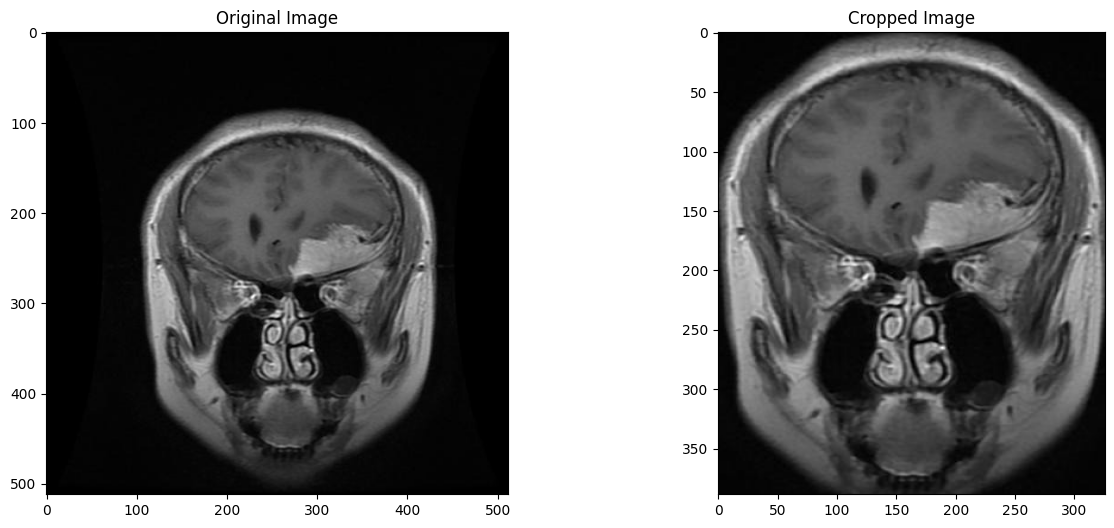

In [ ]:
example_img = cv2.imread(str(train_dir / "meningioma" / "Tr-meTr_0000.jpg"))
cropped_img = crop_image(example_img, plot=True)

In [18]:
# Saving the cropped Images

In [ ]:
def save_cropped_class(src_dir, dst_dir, desc=""):
    """Crop, CLAHE-enhance, resize and save all images for one class."""
    failed = []
    j = 0
    for fname in tqdm(os.listdir(src_dir), desc=desc):
        if fname.startswith('.'):
            continue
        path = src_dir / fname
        img  = cv2.imread(str(path))
        if img is None:
            failed.append(str(path)); continue
        try:
            img = preprocess_mri_clahe(img)
            img = crop_image(img, plot=False)
            img = cv2.resize(img, (240, 240))
            cv2.imwrite(str(dst_dir / f"{j}.jpg"), img)
            j += 1
        except Exception as e:
            failed.append((str(path), str(e)))
    print(f"  {desc}: {j} saved, {len(failed)} failed")
    return failed

all_failed = []
for cls in CLASSES:
    fails = save_cropped_class(train_dir / cls, CROP_DIR / cls, desc=f"Train/{cls}")
    all_failed.extend(fails)

print(f"\nTotal failed: {len(all_failed)}")

100%|██████████| 1321/1321 [00:03<00:00, 340.10it/s]


In [ ]:
for cls in CLASSES:
    print(f"{cls}: {len(os.listdir(CROP_DIR / cls))} cropped images")

1321

In [ ]:
test_failed = []
for cls in CLASSES:
    fails = save_cropped_class(test_dir / cls, TEST_DATA_DIR / cls, desc=f"Test/{cls}")
    test_failed.extend(fails)

print(f"\nTotal test failed: {len(test_failed)}")

100%|██████████| 300/300 [00:00<00:00, 374.94it/s]


In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array

In [ ]:
# ── Richer augmentation for training ─────────────────────────────────────────
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    str(CROP_DIR),
    target_size=(240, 240),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

valid_data = datagen.flow_from_directory(
    str(CROP_DIR),
    target_size=(240, 240),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

# FIX: use test_datagen (no augmentation on test set)
test_datagen = ImageDataGenerator()
test_data = test_datagen.flow_from_directory(
    str(TEST_DATA_DIR),
    target_size=(240, 240),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [30]:
train_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

In [31]:
test_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

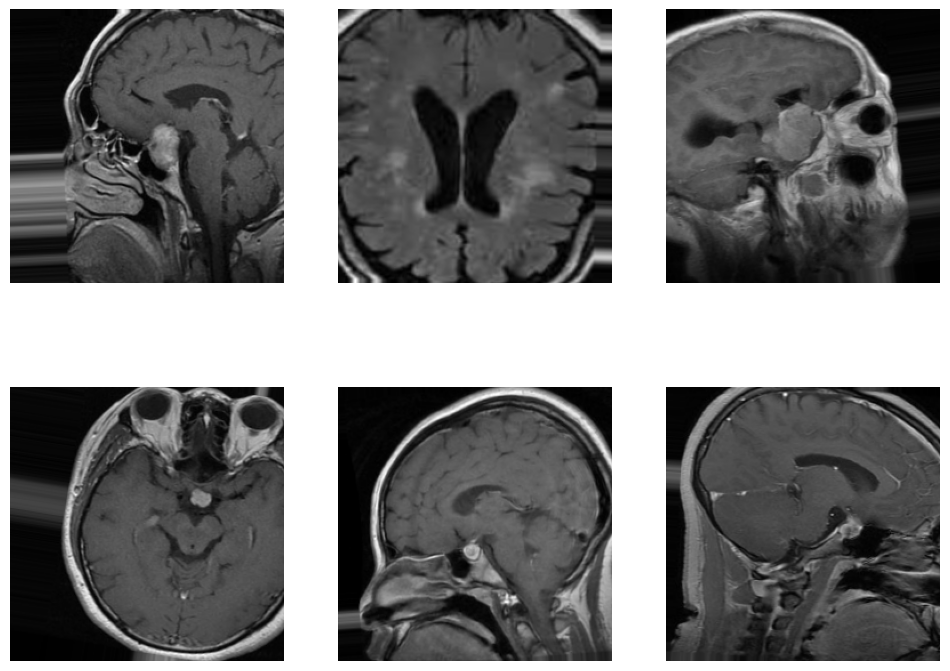

In [32]:
sample_x, sample_y = next(train_data)

plt.figure(figsize = (12, 9))

for i in range(6):
  plt.subplot(2, 3, i+1)
  sample = array_to_img(sample_x[i])
  plt.axis('off')
  plt.grid(False)
  plt.imshow(sample)

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                     BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# ── Phase 1: Freeze base, train classifier head only ─────────────────────────
effenet = EfficientNetB1(weights='imagenet', include_top=False, input_shape=(240, 240, 3))
for layer in effenet.layers:
    layer.trainable = False

x = effenet.output
x = GlobalAveragePooling2D()(x)          # more stable than MaxPooling
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
# dtype='float32' required when using mixed_float16 policy
outputs = Dense(4, activation='softmax', dtype='float32')(x)

model = Model(inputs=effenet.input, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 240, 240,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 240, 240,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 240, 240,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,580,363 (25.10 MB)

 Trainable params: 6,518,308 (24.87 MB)

 Non-trainable params: 62,055 (242.41 KB)

In [ ]:
# ── Class weights (handles class imbalance) ───────────────────────────────────
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", {CLASSES[k]: round(v, 3) for k, v in class_weight_dict.items()})

# ── Compile ───────────────────────────────────────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint('model_phase1.keras', monitor='val_accuracy',
                             save_best_only=True, mode='max', verbose=1)
earlystop  = EarlyStopping(monitor='val_accuracy', patience=5,
                            mode='max', verbose=1, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_accuracy', factor=0.3,
                                patience=2, min_delta=0.001, mode='max', verbose=1)

In [ ]:
%%time
# ── Phase 1 Training: frozen base ────────────────────────────────────────────
print("=== Phase 1: Training classifier head ===")
history_p1 = model.fit(
    train_data,
    epochs=20,
    validation_data=valid_data,
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, earlystop, reduce_lr]
)

Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6872 - loss: 1.9668
Epoch 1: val_accuracy improved from -inf to 0.76599, saving model to model.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 775s 5s/step - accuracy: 0.6877 - loss: 1.9638 - val_accuracy: 0.7660 - val_loss: 1.0905 - learning_rate: 1.0000e-04
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8749 - loss: 0.6473
Epoch 2: val_accuracy improved from 0.76599 to 0.78177, saving model to model.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 812s 6s/step - accuracy: 0.8750 - loss: 0.6469 - val_accuracy: 0.7818 - val_loss: 1.1426 - learning_rate: 1.0000e-04
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9141 - loss: 0.4083
Epoch 3: val_accuracy improved from 0.78177 to 0.81157, saving model to model.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 793s 6s/step - accuracy: 0.9142 - loss: 0.4082 - val_accuracy: 0.8116 - val_loss: 1.0160 - learning_rate: 1.0000e-04
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accur

In [ ]:
%%time
# ── Phase 2: Fine-tune top 30 EfficientNet layers ────────────────────────────
print("=== Phase 2: Fine-tuning top layers ===")
for layer in effenet.layers[-30:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),   # 10x lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_p2 = ModelCheckpoint('model_best.keras', monitor='val_accuracy',
                                save_best_only=True, mode='max', verbose=1)
earlystop_p2  = EarlyStopping(monitor='val_accuracy', patience=7,
                               mode='max', verbose=1, restore_best_weights=True)

history_p2 = model.fit(
    train_data,
    epochs=30,
    validation_data=valid_data,
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_p2, earlystop_p2, reduce_lr]
)

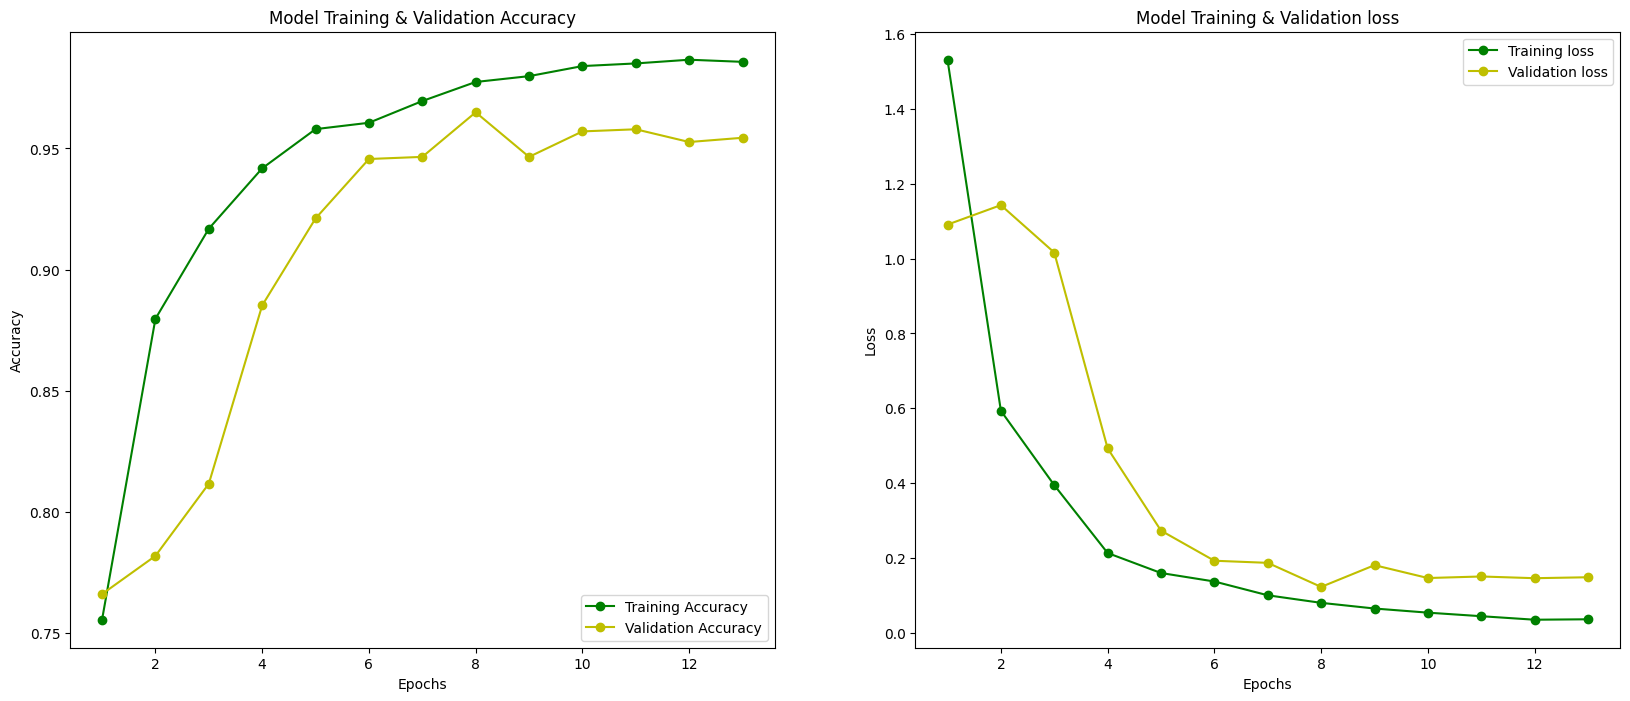

In [ ]:
# Combine Phase 1 + Phase 2 histories for a unified plot
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

train_acc  = combine_history(history_p1, history_p2, 'accuracy')
val_acc    = combine_history(history_p1, history_p2, 'val_accuracy')
train_loss = combine_history(history_p1, history_p2, 'loss')
val_loss   = combine_history(history_p1, history_p2, 'val_loss')
epochs     = range(1, len(train_acc) + 1)
phase_split= len(history_p1.history['accuracy'])  # where phase 2 starts

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

ax[0].plot(epochs, train_acc, 'g-o', label='Training Accuracy')
ax[0].plot(epochs, val_acc,   'y-o', label='Validation Accuracy')
ax[0].axvline(x=phase_split, color='red', linestyle='--', label='Fine-tune start')
ax[0].set_title('Model Accuracy — Phase 1 & 2')
ax[0].legend(loc='lower right')
ax[0].set_xlabel("Epochs"); ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[1].plot(epochs, val_loss,   'y-o', label='Validation Loss')
ax[1].axvline(x=phase_split, color='red', linestyle='--', label='Fine-tune start')
ax[1].set_title('Model Loss — Phase 1 & 2')
ax[1].legend()
ax[1].set_xlabel("Epochs"); ax[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

In [40]:
model.evaluate(train_data)

143/143 ━━━━━━━━━━━━━━━━━━━━ 134s 936ms/step - accuracy: 0.9986 - loss: 0.0045


[0.0033803789410740137, 0.998906135559082]

In [41]:
model.evaluate(test_data)

41/41 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9723 - loss: 0.1165


[0.06958195567131042, 0.9809305667877197]

In [42]:
y_test = test_data.classes
y_test_hat = np.argmax(model.predict(test_data), axis = 1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step 


In [43]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, classification_report

In [44]:
cm = confusion_matrix(y_test, y_test_hat)
cm

array([[280,  19,   0,   1],
       [  0, 305,   0,   1],
       [  0,   0, 405,   0],
       [  0,   3,   0, 297]], dtype=int64)

In [45]:
test_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

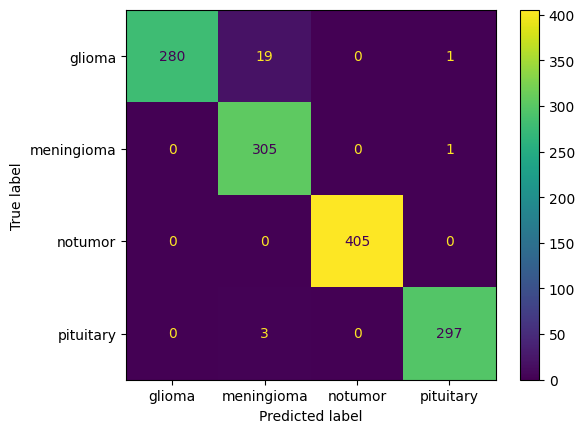

In [46]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['glioma', 'meningioma', 'notumor', 'pituitary'])
cm_display.plot()
plt.show()

In [48]:
print(classification_report(y_test, y_test_hat))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97       300
           1       0.93      1.00      0.96       306
           2       1.00      1.00      1.00       405
           3       0.99      0.99      0.99       300

    accuracy                           0.98      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.98      0.98      0.98      1311



In [ ]:
# ── Per-Class ROC Curves + AUC ───────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_score = model.predict(test_data)
y_bin   = label_binarize(y_test, classes=[0, 1, 2, 3])
label_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorchid']

for i, (cls_name, color) in enumerate(zip(label_names, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    axes[i].plot(fpr, tpr, color=color, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[i].set_title(f'{cls_name}')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right')
    axes[i].set_xlim([0, 1]); axes[i].set_ylim([0, 1.02])

plt.suptitle('Per-Class ROC Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
# Prediction on Test Img

In [ ]:
import PIL

CLASS_DICT = {0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}

images     = []
prediction = []
original   = []

for cls in os.listdir(str(TEST_DATA_DIR)):
    if cls.startswith('.'):
        continue
    cls_dir = TEST_DATA_DIR / cls
    for item in os.listdir(str(cls_dir)):
        if item.startswith('.'):
            continue
        img_path = cls_dir / item
        img = PIL.Image.open(str(img_path)).convert('RGB')
        images.append(img)
        img_arr = np.array(img.resize((240, 240)))
        pred = model.predict(np.expand_dims(img_arr, axis=0), verbose=0)
        prediction.append(CLASS_DICT[np.argmax(pred)])
        original.append(cls)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━

In [56]:
score = accuracy_score(original, prediction)
score

0.9839816933638444

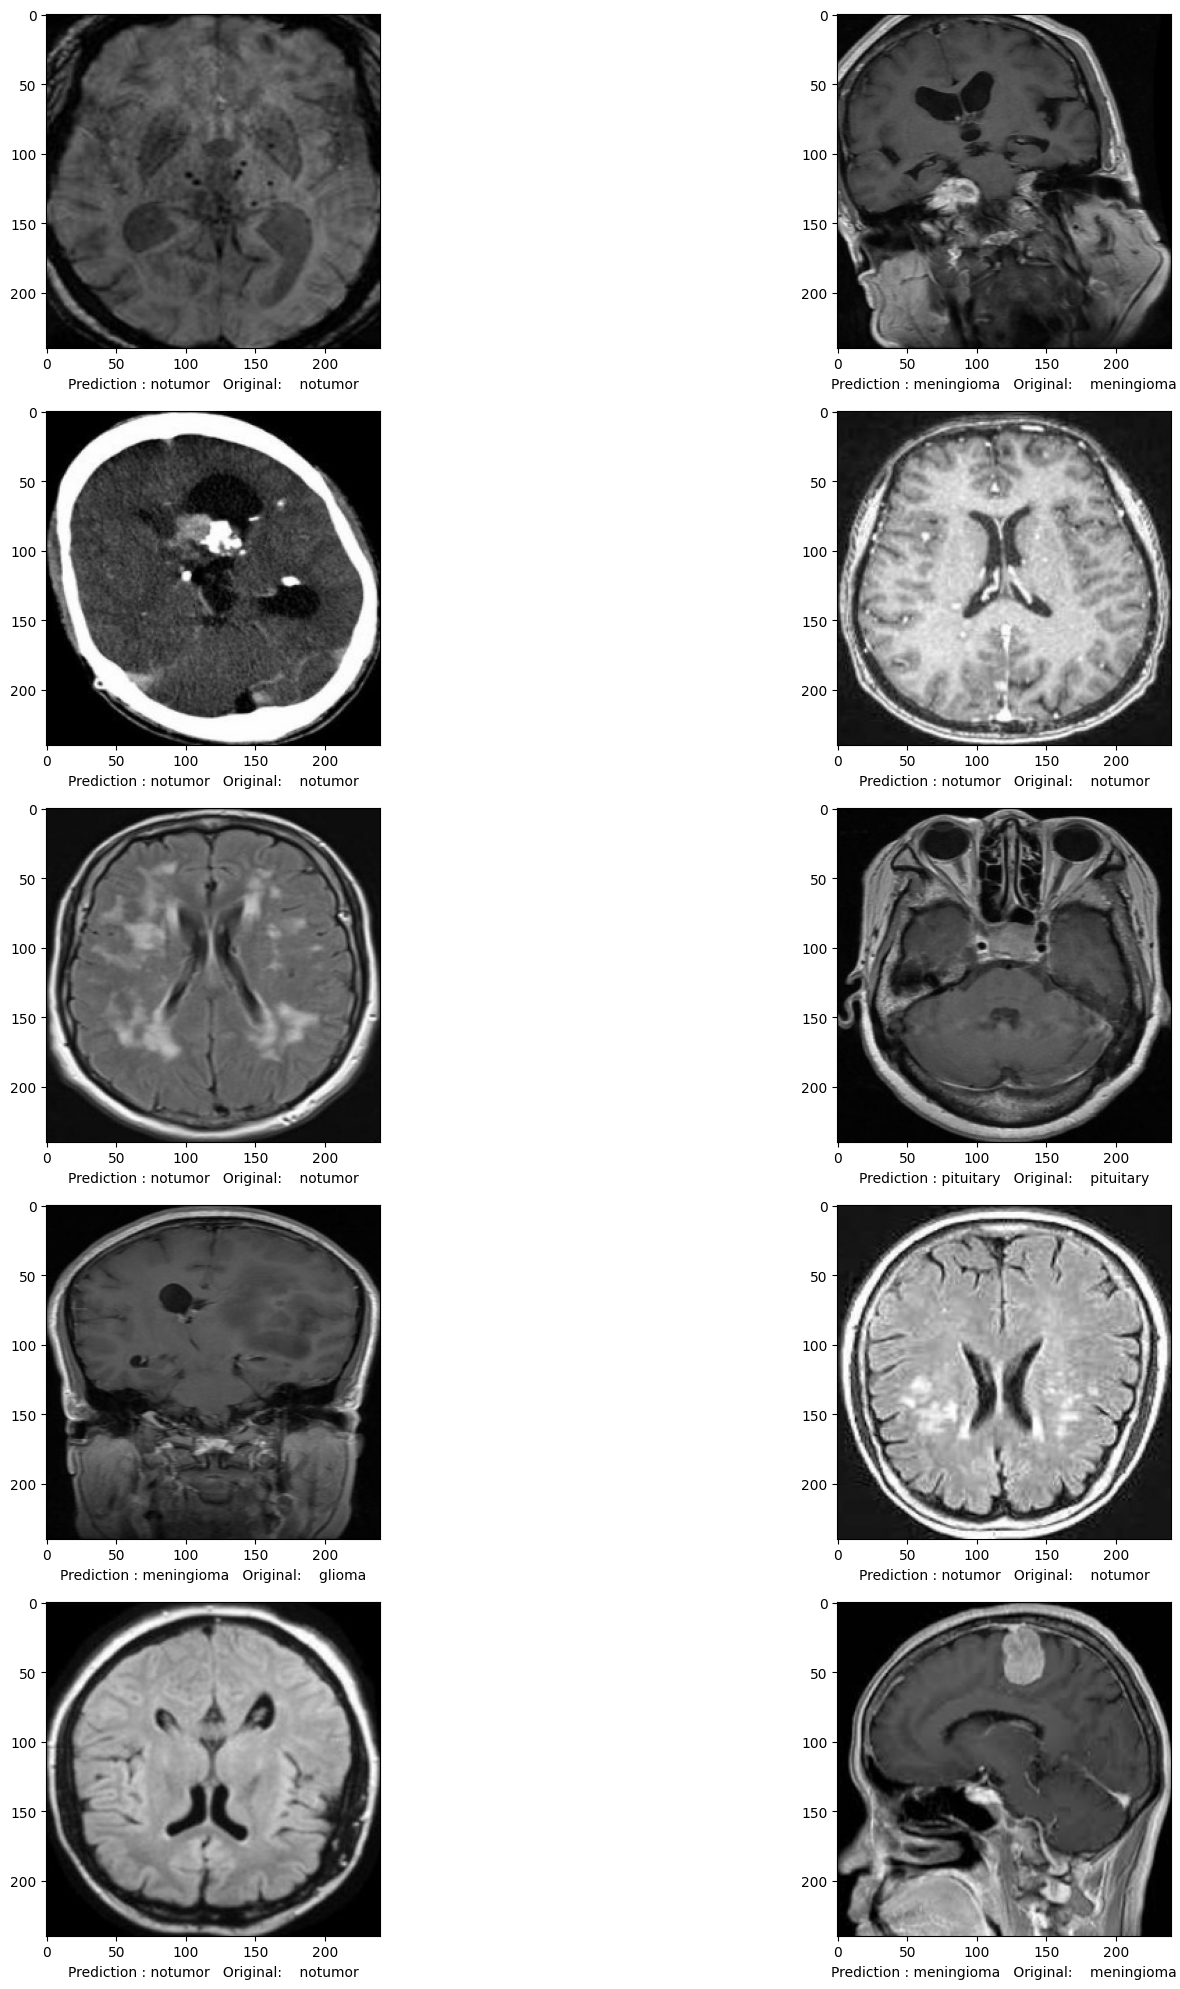

In [ ]:
fig = plt.figure(figsize=(20, 20))

for i in range(10):
    j = random.randint(0, len(images) - 1)   # FIX: -1 avoids IndexError
    fig.add_subplot(5, 2, i + 1)
    correct = prediction[j] == original[j]
    color   = 'green' if correct else 'red'
    plt.xlabel(f"Pred: {prediction[j]}   True: {original[j]}", color=color)
    plt.imshow(images[j])
    plt.axis('off')

fig.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import tensorflow.keras as K
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array


# ── Grad-CAM++ ────────────────────────────────────────────────────────────────
def GradCAMPlusPlus(model, image):
    """
    Grad-CAM++: second-order gradient method giving sharper,
    more spatially accurate heatmaps than standard Grad-CAM.
    Returns an RGB heatmap resized to the input image dimensions.
    """
    last_conv = next(x for x in model.layers[::-1] if isinstance(x, K.layers.Conv2D))
    grad_model = Model([model.inputs], [last_conv.output, model.output])

    img_batch = np.expand_dims(image, axis=0).astype('float32')

    with tf.GradientTape() as tape3:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape1:
                conv_out, preds = grad_model(img_batch)
                pred_idx = tf.argmax(preds[0])
                loss = preds[:, pred_idx]
            grads1 = tape1.gradient(loss, conv_out)
        grads2 = tape2.gradient(grads1, conv_out)
    grads3 = tape3.gradient(grads2, conv_out)

    # Alpha weights (Grad-CAM++ formula)
    global_sum = tf.reduce_sum(conv_out, axis=(1, 2), keepdims=True)
    alpha_denom = 2.0 * grads2 + global_sum * grads3 + 1e-7
    alpha = grads2 / alpha_denom
    weights = tf.reduce_sum(alpha * tf.nn.relu(grads1), axis=(1, 2))[0]

    # Weighted combination of feature maps
    cam = tf.reduce_sum(weights * conv_out[0], axis=-1).numpy()
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (image.shape[1], image.shape[0]))
    if cam.max() > 0:
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    return cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB), int(pred_idx)


def VizGradCAMPlusPlus(model, image, interpolant=0.5, class_dict=None):
    """
    Display a 4-panel figure:
      Original | Heatmap | Overlay | Confidence bar
    """
    assert 0 < interpolant < 1, "interpolant must be between 0 and 1"

    img_arr = np.array(image, dtype='float32')
    heatmap, pred_idx = GradCAMPlusPlus(model, img_arr)

    # Normalise original to 0-255 uint8
    orig_norm = np.uint8(
        (img_arr - img_arr.min()) / (img_arr.max() - img_arr.min() + 1e-7) * 255
    )

    # Resize heatmap to match image
    heatmap_rs = cv2.resize(heatmap, (orig_norm.shape[1], orig_norm.shape[0]))
    overlay = np.uint8(orig_norm * interpolant + heatmap_rs * (1 - interpolant))

    # Confidence scores
    probs = model.predict(np.expand_dims(img_arr, 0), verbose=0)[0]
    labels = class_dict or {i: str(i) for i in range(len(probs))}

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    plt.rcParams['figure.dpi'] = 100

    axes[0].imshow(orig_norm); axes[0].set_title('Original MRI');    axes[0].axis('off')
    axes[1].imshow(heatmap_rs); axes[1].set_title('Grad-CAM++ Heatmap'); axes[1].axis('off')
    axes[2].imshow(overlay);   axes[2].set_title('Overlay');            axes[2].axis('off')

    # Confidence bar chart
    bar_colors = ['tomato' if i == pred_idx else 'steelblue' for i in range(len(probs))]
    axes[3].barh([labels[i] for i in range(len(probs))], probs, color=bar_colors)
    axes[3].set_xlim(0, 1); axes[3].set_xlabel('Confidence')
    axes[3].set_title(f'Prediction: {labels[pred_idx]} ({probs[pred_idx]*100:.1f}%)')

    plt.suptitle('Grad-CAM++ Explainability', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return overlay

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


C:\Users\My PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 240, 240, 3))
  warnings.warn(msg)


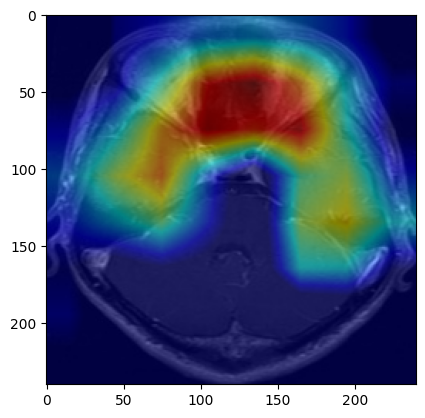

In [ ]:
CLASS_NAMES = {0: 'Glioma', 1: 'Meningioma', 2: 'No Tumor', 3: 'Pituitary'}

# Run Grad-CAM++ on one sample from each class
for cls_idx, cls_name in CLASS_NAMES.items():
    cls_dir  = TEST_DATA_DIR / CLASSES[cls_idx]
    img_files = [f for f in os.listdir(str(cls_dir)) if not f.startswith('.')]
    if not img_files:
        continue
    img_path = cls_dir / img_files[0]
    test_img = cv2.imread(str(img_path))
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    test_img = cv2.resize(test_img, (240, 240))
    print(f"\n── {cls_name} ──")
    VizGradCAMPlusPlus(model, test_img, interpolant=0.5, class_dict=CLASS_NAMES)

In [ ]:
# ── Monte Carlo Dropout — Uncertainty Quantification ─────────────────────────
# Critical for medical AI: the model reports HOW CONFIDENT it is.
# High uncertainty → flag for specialist review.

def predict_with_uncertainty(model, image, n_iterations=50):
    """
    Run inference n times with dropout active.
    Returns mean prediction and per-class uncertainty (std).
    """
    img_batch = np.expand_dims(np.array(image, dtype='float32'), axis=0)
    preds = np.array([
        model(img_batch, training=True).numpy()   # training=True keeps Dropout ON
        for _ in range(n_iterations)
    ])                                              # shape: (N, 1, 4)
    preds = preds[:, 0, :]                          # shape: (N, 4)
    return preds.mean(axis=0), preds.std(axis=0)


# Demo on one sample per class
print("Monte Carlo Dropout Uncertainty (50 forward passes)\n")
print(f"{'Class':<15} {'Predicted':<15} {'Confidence':>12} {'Uncertainty':>13}")
print("-" * 58)

for cls_idx, cls_name in CLASS_NAMES.items():
    cls_dir   = TEST_DATA_DIR / CLASSES[cls_idx]
    img_files = [f for f in os.listdir(str(cls_dir)) if not f.startswith('.')]
    if not img_files:
        continue
    img_path = cls_dir / img_files[1]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (240, 240))

    mean_pred, uncertainty = predict_with_uncertainty(model, img)
    pred_cls  = CLASS_NAMES[np.argmax(mean_pred)]
    confidence = mean_pred.max() * 100
    unc_val    = uncertainty[np.argmax(mean_pred)] * 100
    flag = " ⚠ UNCERTAIN — refer to specialist" if unc_val > 5.0 else ""
    print(f"{cls_name:<15} {pred_cls:<15} {confidence:>10.1f}%  ±{unc_val:>5.1f}%{flag}")

In [ ]:
# ── Test-Time Augmentation (TTA) — Free +1-2% accuracy ───────────────────────
# Runs inference 10x with slight augmentations and averages predictions.

def predict_with_tta(model, image, n_augments=10):
    augmenter = ImageDataGenerator(
        rotation_range=10,
        zoom_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1]
    )
    img_batch = np.expand_dims(np.array(image, dtype='float32'), axis=0)
    preds = [model.predict(next(augmenter.flow(img_batch, batch_size=1)), verbose=0)
             for _ in range(n_augments)]
    return np.mean(preds, axis=0)[0]


# ── TTA accuracy on test set ──────────────────────────────────────────────────
print("Computing TTA predictions on test set ...")
tta_preds  = []
tta_labels = []

for cls_idx, cls_name in CLASS_NAMES.items():
    cls_dir   = TEST_DATA_DIR / CLASSES[cls_idx]
    img_files = [f for f in os.listdir(str(cls_dir)) if not f.startswith('.')][:20]  # 20 per class
    for fname in tqdm(img_files, desc=cls_name):
        img = cv2.imread(str(cls_dir / fname))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (240, 240))
        tta_p = predict_with_tta(model, img)
        tta_preds.append(np.argmax(tta_p))
        tta_labels.append(cls_idx)

from sklearn.metrics import accuracy_score as acc_score
tta_accuracy = acc_score(tta_labels, tta_preds)
print(f"\nTTA Accuracy (20 samples/class): {tta_accuracy*100:.2f}%")

In [ ]:
# ── Gradio Interactive Web App ────────────────────────────────────────────────
# Upload any MRI → get prediction + Grad-CAM++ heatmap + uncertainty score.
import gradio as gr

def predict_mri(pil_image):
    img = np.array(pil_image.convert('RGB').resize((240, 240)))

    # Standard prediction
    probs = model.predict(np.expand_dims(img, 0), verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx]) * 100

    # Monte Carlo uncertainty
    _, uncertainty = predict_with_uncertainty(model, img, n_iterations=30)
    unc_val = float(uncertainty[pred_idx]) * 100

    # Grad-CAM++ heatmap
    heatmap, _ = GradCAMPlusPlus(model, img)
    heatmap_rs = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    overlay    = np.uint8(img * 0.5 + heatmap_rs * 0.5)

    label = (f"Prediction: {CLASS_NAMES[pred_idx]}\n"
             f"Confidence: {confidence:.1f}%  ±{unc_val:.1f}%\n"
             + (" ⚠ Low confidence — consider specialist review" if unc_val > 5 else " ✓ High confidence"))

    return PIL.Image.fromarray(overlay), label


demo = gr.Interface(
    fn=predict_mri,
    inputs=gr.Image(type="pil", label="Upload MRI Scan"),
    outputs=[gr.Image(label="Grad-CAM++ Overlay"), gr.Textbox(label="Result")],
    title="Brain Tumor MRI Classifier",
    description="Upload an MRI scan → get tumor class, confidence, uncertainty, and Grad-CAM++ heatmap.",
    examples=[[str(TEST_DATA_DIR / CLASSES[0] / f)]
              for f in os.listdir(str(TEST_DATA_DIR / CLASSES[0]))[:2]
              if not f.startswith('.')]
)
demo.launch(share=False)

In [ ]:
# ── TensorFlow Lite Export (mobile / edge deployment) ────────────────────────
print("Converting to TFLite with INT8 quantization ...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # post-training quantization
tflite_model = converter.convert()

tflite_path = BASE_DIR / "brain_tumor_model.tflite"
tflite_path.write_bytes(tflite_model)
print(f"TFLite model saved → {tflite_path}  "
      f"({tflite_path.stat().st_size / 1e6:.1f} MB)")

# ── Verify TFLite model ───────────────────────────────────────────────────────
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()
inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]

# Run one inference to confirm it works
sample_img = np.zeros((1, 240, 240, 3), dtype=np.float32)
interpreter.set_tensor(inp['index'], sample_img)
interpreter.invoke()
tflite_pred = interpreter.get_tensor(out['index'])
print(f"TFLite test inference output shape: {tflite_pred.shape}  ✓")